**Important Note:** You should have first uploaded the **entire** folder for Problem Sheet 2 to your Google Drive, and open this file with Google Colab through your drive. (You are advised against opening this file directly in Google Colab.)

# Question 1: Classifying digits in the MNIST dataset

We would like to classify the digits from the MNIST dataset, with the data in the form $(x_i, y_i)$ with $x_i \in \mathbb{R}^{d\times d}$ ($d=28$) being the image and $y_i \in \mathbb{R}^K$ ($K=10$) being the labels using a single convolutional neural network with `5` channels, each with `3*3` filters.

Make sure you are happy with the derivation of the steps of stochastic gradient descent for a single-layer multi-channel convolutional neural network. You may either refer to page 107-114 of the slides for lectures 1-3, or the course lecture notes on neural networks.

**Note on vectorisation:** it is acceptable to use `for` loop for batch gradient descent.

Once again, we have setup the environments for you. This is done by running the following cell. Remember <font color=red>**always**</font> run the code cell below each time before you attempt this question.

In [ ]:
# import necessary package
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
import h5py
from tqdm import tqdm
from random import randint

## Part (a) - Implementing the convolution operator

**(i)** Implement the `Convolution` function. The `Convolution` function should input
- `X` as the image (2D array), and
- `F` as an 3D array that represents filters from `F.shape[0]` channels, each with shape `(F.shape[1], F.shape[2])`.

The output `Z` should be an 3D array of shape `(F.shape[0], dim_x, dim_y)` that represents convolved images of shape `(dim_x, dim_y)` from `F.shape[0]` channels.



In [ ]:
def Convolution(X, F):
  # TODO: fill in the following
  n_channel = "fill in me"
  dim_x = "fill in me"
  dim_y = "fill in me"

  Z = np.zeros((n_channel, dim_x, dim_y))

  # TODO: fill in the entries of Z

  for i in range(dim_x):
    for j in range(dim_y):
      Z[:,i,j] = "fill in me"

  return Z

**(ii)** We shall now test the `Convolution` operator. **Your task is to figure out what the filter does to the testing image**. The testing image is available at `radcam.jpg`.

To complete this part:
- upload the file `radcam.jpg` to Google Colab, or
- make sure that `radcam.jpg` is at the same directory at this notebook.

In [ ]:
raw_img = cv2.imread('radcam.jpg')
test_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)

You can run this cell to preview the file.

array([[117, 116, 115, ..., 139, 141, 141],
       [118, 117, 117, ..., 140, 143, 143],
       [120, 119, 118, ..., 143, 144, 144],
       ...,
       [ 36,  41,  41, ..., 102,  95,  86],
       [ 41,  44,  42, ...,  86,  86,  81],
       [ 58,  56,  47, ...,  85,  90,  87]], dtype=uint8)
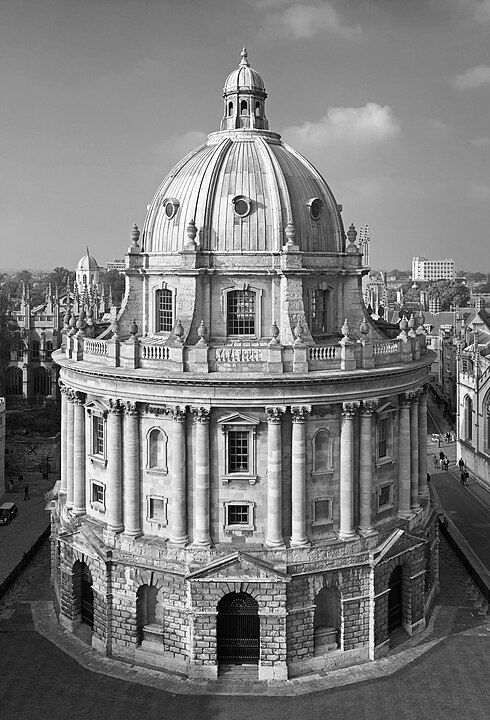

In [ ]:
test_img

All filters (of size `(3,3)`) are contained in the following `test_F`.

In [ ]:
test_F = np.array([
    [[1/16, 1/8, 1/16], [1/8, 1/4, 1/8], [1/16, 1/8, 1/16]],
    [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],
    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    [[1, 2, 1], [0, 0, 0], [-1, -2, -1]],
])

In [ ]:
conv_img = Convolution(test_img, test_F)

Now run the following cell to view the processed images. **Can you figure out what do the filters do?**

If you are running this cell locally, you should use the function `cv2.imshow` instead.

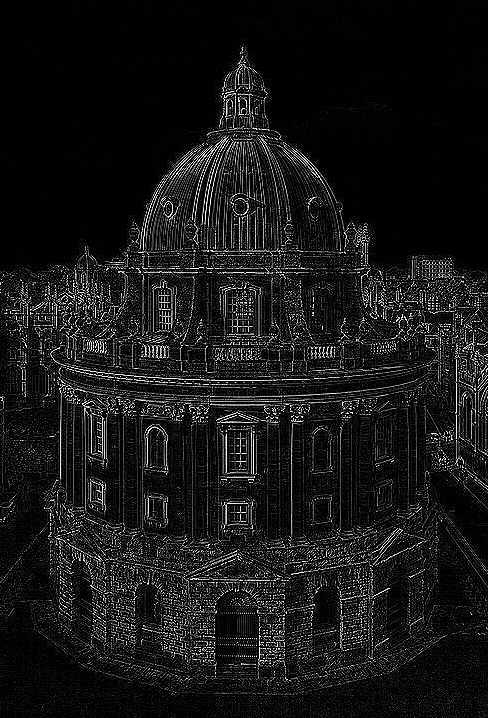

In [ ]:
channel = 1                     # could be 0, 1, 2 or 3
cv2_imshow(conv_img[channel])

## Part (b) - implementing the  CNN from scratch

**Step 1:** upload the MNIST dataset and run the following cell.

In [ ]:
#load MNIST data
MNIST_data = h5py.File('MNISTdata.hdf5', 'r')
x_train = np.float32(MNIST_data['x_train'][:] )
y_train = np.int32(np.array(MNIST_data['y_train'][:,0]))
x_test = np.float32( MNIST_data['x_test'][:] )
y_test = np.int32( np.array( MNIST_data['y_test'][:,0]  ) )

MNIST_data.close()

x_train2 = np.zeros((len(x_train), 28, 28))
x_test2 = np.zeros((len(x_test), 28, 28))

#Re-create 2-D arrays for each image.
for i in range(len(x_train)):
    x_train2[i,:,:] = np.reshape(x_train[i], (28,28) )

for i in range(len(x_test)):
    x_test2[i,:,:] = np.reshape(x_test[i], (28,28) )

**Step 2:** Implement the ReLU activation function, its derivative, as well as the softmax function.

In [ ]:
# TODO: replace the "pass" with your implementation of the following functions
def ReLU_nonlinearity(z):
  pass

def ReLU_nonlinearity_derivative(z):
  pass

def softmax_function(z):
  pass

We are now ready to implement our convolutional neural network as an object called `myCNN`. The remaining steps are followed:

**Step 3:** Initialise the filters `K`, weights `W` and the biases `b` respectively. (*Hint:* the shape of weights `W` is `(self.num_channels, d2, d2)`, where `d2` is an integer to be specified.)

**Step 4:** Implement the `forward` function, which has `X` as the input figure and output
- `p` as the final probability vector
- `V` as the output of convolution
- `H` as $\sigma(V)$, and
- `Z` as $W \cdot H + b$.

**Step 5:** Implement the `backward` function, which has `X` as the input figure, `y` as the labels, `p`, `V`, `H`, `Z` as defined in step 4 as an optional argument, and output `K_grad`, `W_grad` and `b_grad` as the gradient of loss with respect to the filters, weights and biases respectively.

**Step 6:** Complete the `train` function, which inputs the training data (`x_train` and `y_train`) and update the parameters by stochastic gradient descent.

**Step 7:** Complete the `predict` and `test` function. The `predict` function gives out the predicted label given an image input (`x_test`), while the `test` function reports the testing accuracy and generates a confusion matrix when the testing data (`x_test` and `y_test`) are supplied (*Hint:* refer to the relevant codes in Homework 1).

In [ ]:
class myConvolutionalNeuralNetwork:
  def __init__(self, input_size=28, num_outputs=10, filter_size=3, num_channels=5, sk=1, sw=1, sb=1):
    self.input_size = input_size
    self.num_outputs = num_outputs
    self.filter_size = filter_size
    self.num_channels = num_channels
    self.sk = sk
    self.sw = sw
    self.sb = sb

    ### Step 3: initialisation
    # TODO: Compute the dimension of W
    d2 = "fill in me"

    # TODO: Perform the actual initialisation
    self.K = "fill in me"
    self.W = "fill in me"
    self.b = "fill in me"
    ### End of step (3).

  ### Step (4): implement the forward function
  def forward(self, X):
    # TODO: implement the forward function
    pass
  ### End of step (4).

  ### Step (5): implement the backward function
  def backward(self, X, y):
    # TODO: perform the forward step if it hasn't been done so
    # TODO: compute the gradient for b
    # TODO: compute the gradient for W
    # TODO: compute the gradient for K
    return K_grad, W_grad, b_grad
  ### End of TODO (5)

  def train(self, x_train, y_train, LR=.01, num_epochs=1):
    time1 = time.time()

    ### Step (6): implement the train function
    for epoch in range(num_epochs):
      total_correct = 0
      for n in tqdm(range(len(y_train))):

        # TODO: pick a random data
        y = "fill in me"
        x = "fill in me"

        # TODO: perform a forward pass

        # TODO: make a prediction and compute the accuracy

        # TODO: perform a backward propagation

      print(f"Epoch {epoch}: training accuracy {total_correct/len(y_train)}")
      ### End of TODO (6)

    time2 = time.time()
    print(f"Training time is {time2-time1}s.")

  ### TODO (7): implement the predict and test functions
  def predict(self, x_test):
    y_pred = np.zeros(len(y_test))
    pass

  def test(self, x_test, y_test, plot_confusion=False):
    y_pred = self.predict(x_test)
    accuracy = "fill in me"
    pass

  ### End of TODO (7)

Once you are happy with the above implementation, run the following cell to see the performance of your implementation. It takes around 8 minutes for me to finish training.

In [ ]:
my_CNN = myConvolutionalNeuralNetwork()
my_CNN.train(x_train2, y_train)

100%|██████████| 60000/60000 [07:58<00:00, 125.33it/s]

Epoch 0: training accuracy 0.9573166666666667
Training time is 478.760050535202s.


100%|██████████| 10000/10000 [01:15<00:00, 132.01it/s]


0.9661

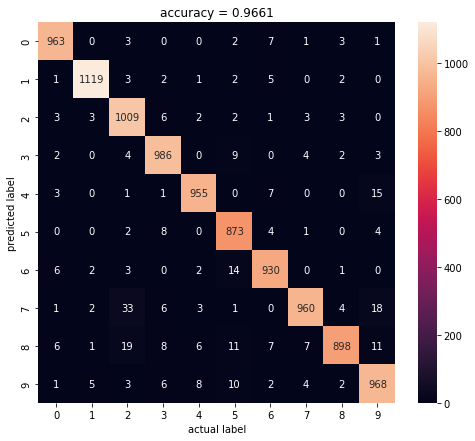

In [ ]:
my_CNN.test(x_test2, y_test, plot_confusion=True)